# MODUL 3 <br>
**Nama : M. Alfatih** <br>
**NIM : F1D02410013** <br>
**KLP : 1**

# Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

Kode di atas digunakan untuk mengimpor tiga library yaitu matplotlib.pyplot, numpy, dan cv2 (yang merupakan alias untuk library OpenCV). matplotlib.pyplot digunakan untuk membuat visualisasi grafik, plot, dan grafik lainnya di Python. Dalam kode ini, kita akan menggunakan pyplot untuk membuat plot gambar. numpy adalah library Python yang digunakan untuk bekerja dengan array dan matriks. cv2 adalah library OpenCV (Open Source Computer Vision Library) yang digunakan untuk memproses gambar.

# Persiapan Citra

Kode ini berfungsi memuat citra "backup.jpg" langsung dalam format grayscale menggunakan parameter cv2.IMREAD_GRAYSCALE. Konversi awal ini dilakukan untuk menyederhanakan data gambar menjadi satu kanal intensitas cahaya saja, sehingga memperingan beban komputasi untuk proses deteksi tepi selanjutnya. Citra kemudian ditampilkan ke layar menggunakan fungsi dari pustaka Matplotlib.

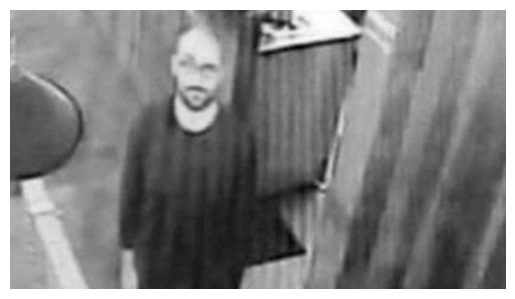

In [2]:
gambar1 = cv2.imread("backup.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(gambar1, cmap="gray")
plt.axis("off")
plt.show()

Visualisasi di atas menampilkan citra asli dalam domain spasial setelah dikonversi ke format grayscale. Proses ini bertujuan untuk menghilangkan informasi kromatid (warna) dan menyisakan nilai luminansi (kecerahan) tiap piksel. Hal ini penting untuk memperjelas kontras antara objek dan latar belakang sebelum dilakukan operasi deteksi tepi.

# Deklarasi fungsi yang  dibutuhkan

Fungsi dibawah ini adalah filter_citra yang merupakan implementasi filter spasial untuk perbaikan kualitas citra menggunakan pendekatan statistik pada domain spasial. Fungsi ini mendukung tiga metode utama: Mean Filter yang menghitung nilai rata-rata piksel dalam jendela kernel untuk mereduksi noise halus dan menghaluskan citra, Median Filter yang menggunakan algoritma pengurutan (Bubble Sort manual) untuk mengambil nilai tengah guna menghilangkan noise salt-and-pepper secara efektif, serta Modus Filter yang memilih nilai dengan frekuensi kemunculan tertinggi. Untuk menjaga dimensi citra agar tidak mengecil setelah proses konvolusi, fungsi ini menerapkan teknik padding pada tepi citra sebelum melakukan pemindaian jendela (windowing) secara manual ke seluruh koordinat piksel.

In [3]:
def filter_citra(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total_sum = 0
                    for row in region:
                        for pixel in row:
                            total_sum += int(pixel)
                    
                    canvas[i, j] = total_sum // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = []
                    for row in region:
                        for val in row:
                            values.append(val)
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val
    return canvas

Fungsi convolution di bawah merupakan implementasi dasar dari operasi pemrosesan citra dalam domain spasial. Proses diawali dengan menerapkan padding pada citra asli agar ukuran output tetap konsisten dengan input setelah dilakukan perhitungan. Secara teknis, fungsi ini melakukan pemindaian jendela (windowing) ke seluruh permukaan citra, di mana setiap piksel pada area yang terpilih akan dikalikan dengan nilai koefisien kernel yang bersesuaian, lalu seluruh hasilnya dijumlahkan untuk menjadi nilai piksel baru pada kanvas output

In [4]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            # Area kernel
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas

Blok kode di bawah ini mendefinisikan berbagai jenis matriks kernel yang akan digunakan sebagai filter dalam operasi konvolusi citra. Kernel Smoothing dan Sharpening bekerja pada domain perbaikan kualitas citra, di mana smoothing meratakan intensitas piksel untuk mengurangi noise, sedangkan sharpening memperkuat perbedaan kontras untuk memperjelas detail. Selanjutnya, didefinisikan pula operator deteksi tepi seperti Sobel, Prewitt, dan Roberts. Operator Sobel dan Prewitt menggunakan kernel berukuran $3 \times 3$ untuk menghitung gradien intensitas pada arah horizontal ($x$) dan vertikal ($y$), di mana Sobel memberikan bobot lebih pada piksel pusat untuk hasil yang lebih halus. Sementara itu, operator Roberts menggunakan kernel $2 \times 2$ yang lebih sederhana untuk mendeteksi tepi secara diagonal dengan fokus pada perbedaan intensitas yang sangat lokal.

In [5]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

Fungsi edge_detection di bawah mengimplementasikan algoritma deteksi tepi berbasis gradien dengan menggabungkan hasil konvolusi dari dua arah yang berbeda. Proses dimulai dengan menghitung besaran gradien horizontal ($gx$) dan vertikal ($gy$) menggunakan kernel turunan pertama yang dilewatkan pada fungsi konvolusi. Untuk mendapatkan magnitudo tepi secara keseluruhan, fungsi ini menjumlahkan nilai absolut dari kedua gradien tersebut. Terakhir, dilakukan normalisasi nilai ke rentang $0$ hingga $255$ dan pemangkasan (clipping) piksel agar sesuai

In [6]:
def edge_detection(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    canvas = np.abs(gx) + np.abs(gy)
    
    if np.max(canvas) != 0:
        canvas = (canvas * 255.0) / np.max(canvas)
    
    return np.clip(canvas, 0, 255).astype(np.uint8)

Fungsi dibawah ini melakukan penskalaan intensitas piksel secara manual ke rentang standar 0–255. Tahapan diawali dengan mencari nilai minimum dan maksimum dalam citra melalui perulangan, kemudian setiap piksel ditransformasi menggunakan rumus linear agar distribusi warnanya kembali normal. Proses ini sangat penting untuk memperbaiki kontras dan mencegah data pecah (overflow) akibat operasi matematika sebelumnya yang menghasilkan nilai di luar batas kapasitas data 8-bit.

In [7]:
def normalisasi(citra):
    min_val = int(citra[0,0])
    max_val = int(citra[0,0])
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            if citra[i,j] < min_val: min_val = int(citra[i,j])
            if citra[i,j] > max_val: max_val = int(citra[i,j])
    
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hasil[i,j] = int((int(citra[i,j]) - min_val) / (max_val - min_val) * 255)
    return hasil

# Smoothing, Sharpening, dan Kombinasi

Blok kode ini mendemonstrasikan perbandingan dua teknik perbaikan kualitas citra melalui operasi konvolusi serta efek penggabungannya. Pada sub-plot pertama, dilakukan proses Smoothing menggunakan kernelSmoothing yang bertujuan untuk meminimalkan noise dan meratakan variasi intensitas piksel sehingga citra tampak lebih halus. Sub-plot kedua menampilkan hasil Sharpening dengan kernelSharpening untuk mempertegas detail dan mempertajam transisi intensitas pada tepi objek. Terakhir, dilakukan operasi penjumlahan matriks antara hasil smoothing dan sharpening untuk menggabungkan karakter kedua filter tersebut, yang secara visual berupaya menyeimbangkan antara reduksi noise dan kejelasan detail tekstur pada citra output.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

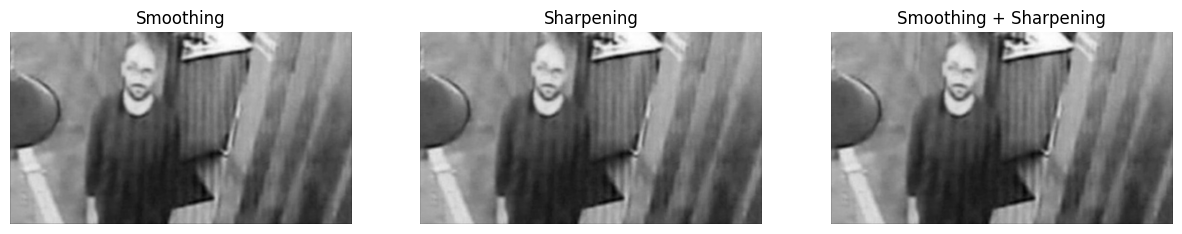

In [8]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
konvosmooth = convolution(gambar1, kernelSmoothing)
plt.imshow(konvosmooth, cmap="gray")
plt.title("Smoothing")
plt.axis("off")

plt.subplot(1, 3, 2)
konvosharp = convolution(gambar1, kernelSharpening)
plt.imshow(konvosharp, cmap="gray")
plt.title("Sharpening")
plt.axis("off")

hasil_tambah = konvosmooth.astype(np.float32) + konvosharp.astype(np.float32)
gabungan = normalisasi(hasil_tambah)
plt.subplot(1, 3, 3)
plt.imshow(gabungan, cmap="gray")
plt.title("Smoothing + Sharpening")
plt.axis("off")

**Perbedaan Metode Perbaikan Kualitas Citra** <br>
Dalam pengolahan citra digital, perbaikan kualitas dilakukan untuk menonjolkan fitur tertentu atau menghilangkan gangguan yang muncul saat akuisisi citra. Perbedaan mendasar dari ketiga metode yang telah divisualisasikan terletak pada cara manipulasi nilai piksel terhadap tetangganya melalui kernel konvolusi. Smoothing bekerja dengan meratakan nilai intensitas untuk mengurangi variasi piksel yang mendadak, sementara Sharpening bekerja sebaliknya dengan memperkuat perbedaan intensitas guna mempertegas batas antarobjek. Penggabungan keduanya (Smoothing + Sharpening) merupakan teknik kompromi untuk mendapatkan citra yang lebih bersih namun tetap memiliki struktur tepi yang kuat.

1. Smoothing (Penghalusan): Berfungsi untuk mereduksi noise atau bintik halus pada citra. Secara visual, citra akan terlihat lebih lembut atau sedikit kabur (blur) karena transisi antar piksel dibuat menjadi lebih landai.
2. Sharpening (Penajaman): Berfungsi untuk meningkatkan kontras pada tepi objek sehingga detail citra menjadi lebih jelas. Secara visual, garis-garis halus dan tekstur akan lebih menonjol, namun berisiko memperkuat noise jika citra awal tidak bersih.
3. Smoothing + Sharpening: Berfungsi untuk menyeimbangkan kualitas citra. Proses ini berupaya mengambil keuntungan dari smoothing untuk membuang gangguan, kemudian menggunakan sharpening untuk memulihkan kembali ketajaman fitur utama yang sempat hilang saat proses penghalusan.

Perbedaan Hasil Filter Mean, Median, dan Modus:
1. Mean Filter menghasilkan citra yang paling halus (kabur) karena setiap piksel digantikan oleh nilai rata-rata seluruh tetangganya. Metode ini sangat baik untuk mereduksi noise Gaussian, namun memiliki kelemahan yaitu mengaburkan tepi objek secara signifikan.
2. Median Filter menghasilkan citra yang bersih dari bintik-bintik tajam (Salt-and-Pepper noise) tanpa mengaburkan tepi objek secara drastis. Karena mengambil nilai tengah dari sekumpulan data yang telah diurutkan, nilai piksel ekstrim (sangat gelap atau sangat terang) akan terbuang sepenuhnya.
3. Modus Filter menghasilkan citra dengan area warna yang lebih solid atau seragam karena menggunakan nilai yang paling sering muncul. Filter ini cenderung menyatukan wilayah dengan intensitas serupa, sehingga sering digunakan untuk penyederhanaan warna atau segmentasi awal.

# Deteksi Tepi dan Kombinasi Operator

Tahapan kode dibawah ini bertujuan untuk mengekstraksi fitur garis tepi pada citra dengan membandingkan tiga operator gradien populer, yaitu Prewitt, Sobel, dan Roberts. Secara teknis, setiap operator melakukan penghitungan turunan pertama intensitas piksel untuk mengidentifikasi area perubahan warna yang drastis sebagai batas objek. Prewitt dan Sobel menggunakan jendela $3 \times 3$ yang memberikan keseimbangan antara ketajaman dan reduksi noise, di mana Sobel memiliki keunggulan pada bobot piksel pusat yang menghasilkan tepi lebih halus. Sementara itu, operator Roberts menggunakan kernel $2 \times 2$ yang sangat responsif terhadap tepi diagonal dan perubahan intensitas lokal yang tajam.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

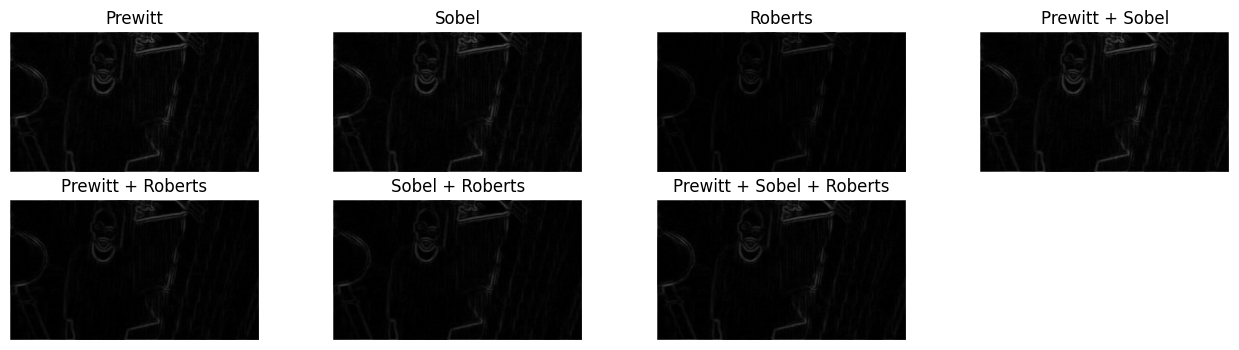

In [9]:
plt.figure(figsize=(16, 4))
plt.subplot(2, 4, 1)
prewitt = edge_detection(gabungan, prewittx, prewitty)
plt.imshow(prewitt, cmap="gray")
plt.title("Prewitt")
plt.axis("off")

plt.subplot(2, 4, 2)
sobel = edge_detection(gabungan, sobelx, sobely)
plt.imshow(sobel, cmap="gray")
plt.title("Sobel")
plt.axis("off")

plt.subplot(2, 4, 3)
roberts = edge_detection(gabungan, robertsx, robertsy)
plt.imshow(roberts, cmap="gray")
plt.title("Roberts")
plt.axis("off")

ps  = normalisasi(prewitt.astype(np.int32) + sobel.astype(np.int32))
pr  = normalisasi(prewitt.astype(np.int32) + roberts.astype(np.int32))
sr  = normalisasi(sobel.astype(np.int32) + roberts.astype(np.int32))
psr = normalisasi(prewitt.astype(np.int32) + sobel.astype(np.int32) + roberts.astype(np.int32))

plt.subplot(2, 4, 4)
plt.imshow(ps, cmap="gray")
plt.title("Prewitt + Sobel")   
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(pr, cmap="gray")
plt.title("Prewitt + Roberts")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(sr, cmap="gray")
plt.title("Sobel + Roberts")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(psr, cmap="gray")
plt.title("Prewitt + Sobel + Roberts")
plt.axis("off")

**Analisis Deteksi Tepi dan Kombinasi Operator Gradien** <br>

Operator Prewitt, Sobel, dan Roberts digunakan untuk mendeteksi tepi objek pada citra CCTV dengan menghitung gradien perubahan intensitas piksel. Operator Sobel dan Prewitt menggunakan kernel $3 \times 3$ yang efektif untuk mengekstraksi struktur garis secara kokoh, kontinu, dan mampu meredam sisa noise, di mana Sobel menghasilkan tepi yang lebih halus pada area tubuh subjek karena pembobotan piksel pusatnya. Sebaliknya, operator Roberts memanfaatkan kernel diagonal $2 \times 2$ yang sangat responsif terhadap perubahan intensitas lokal yang tajam, sehingga unggul dalam menangkap detail kecil seperti fitur wajah subjek, meskipun lebih sensitif terhadap gangguan.
Kombinasi dengan menjumlahkan hasil deteksi bertujuan untuk mengakumulasi informasi dari berbagai algoritma guna menghasilkan garis tepi yang lebih tebal, utuh, dan saling melengkapi. Dalam proses ini, normalisasi setelah penjumlahan menjadi tahapan yang wajib dilakukan untuk memetakan kembali nilai akumulasi piksel yang melampaui batas maksimum 8-bit ($>255$) ke rentang standar $0-255$. Tanpa normalisasi ulang, citra kombinasi akan mengalami overflow atau saturasi (pecah menjadi putih polos) pada titik-titik koordinat yang bertumpuk. Dengan menerapkan fungsi normalisasi manual, distribusi kontras visual tetap terjaga secara proporsional sehingga menghasilkan siluet subjek yang optimal untuk proses segmentasi.

# Perbandingan Threshold Tepi

Fungsi thresholding mengubah citra gradien menjadi citra biner secara manual. Piksel dengan intensitas $\ge$ nilai ambang (angka) akan diubah menjadi putih (255), sedangkan piksel < nilai ambang diubah menjadi hitam (0) untuk memisahkan fitur tepi dari latar belakang. 

In [10]:
def thresholding(image, angka):
    h, w = image.shape
    hasil = np.zeros((h,w), dtype=image.dtype)
    
    for x in range(h):
        for y in range(w):
            if(image[x,y] >= angka):
                hasil[x,y] = 255
            else:
                hasil[x,y] = 0
    return hasil

sepuluh = thresholding(pr, 10)
duaPuluh = thresholding(pr, 20)
tigaPuluh = thresholding(pr, 30)
empatPuluh = thresholding(pr, 40)
limaPuluh = thresholding(pr, 50)
enamPuluh = thresholding(pr, 60)

Nilai Ambang Rendah (10–20) mempertahankan detail garis tepi secara menyeluruh, namun hasil citra menjadi kotor karena sisa noise berintensitas rendah ikut terekstraksi menjadi warna putih. Nilai Ambang Tinggi (50–60) membersihkan gangguan latar belakang secara efektif, tetapi berisiko memutus kontinuitas garis tepi utama serta menghilangkan detail halus pada subjek manusia di citra CCTV tersebut.

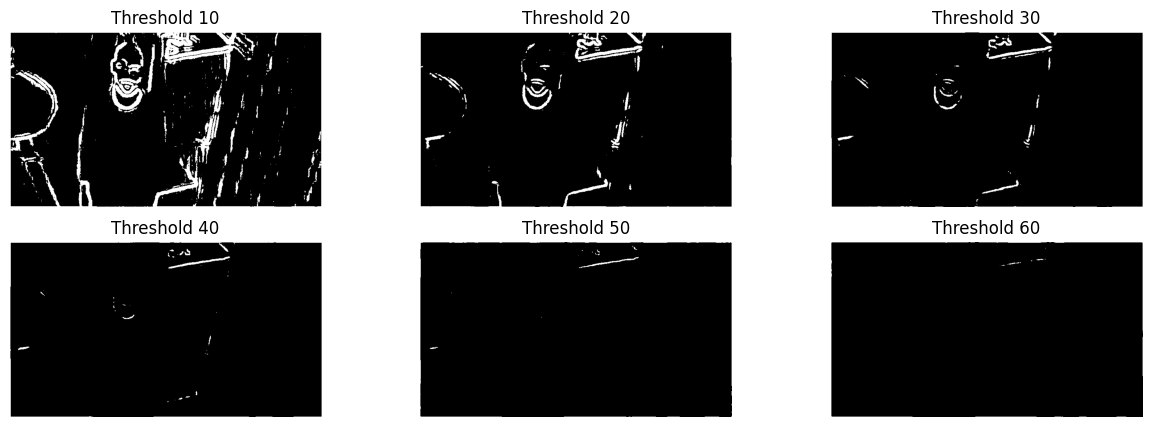

In [11]:
plt.figure(figsize=(15, 5))
plt.subplot(2, 3, 1)
plt.imshow(sepuluh, cmap='gray')
plt.title("Threshold 10")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(duaPuluh, cmap='gray')
plt.title("Threshold 20")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(tigaPuluh, cmap='gray')
plt.title("Threshold 30")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(empatPuluh, cmap='gray')
plt.title("Threshold 40")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(limaPuluh, cmap='gray')
plt.title("Threshold 50")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(enamPuluh, cmap='gray')
plt.title("Threshold 60")
plt.axis("off")
plt.show()


Visualisasi ini menunjukkan pengaruh variasi nilai ambang terhadap hasil segmentasi biner pada citra CCTV yang telah diproses sebelumnya. Nilai ambang rendah (10–20) menghasilkan garis tepi yang sangat lengkap namun dipenuhi oleh bercak noise dari latar belakang, sedangkan nilai ambang yang lebih tinggi (50–60) secara efektif membersihkan gangguan tersebut tetapi berisiko mengikis detail fitur utama dan memutus kontinuitas siluet subjek. Perbandingan ini bertujuan untuk menentukan titik optimal di mana fitur manusia dapat terisolasi secara bersih dari latar belakang tanpa kehilangan informasi struktural yang penting untuk proses pengenalan objek selanjutnya.

Pengaruh & Perbedaan Threshold
Threshold berfungsi memisahkan tepi objek (putih) dari latar belakang (hitam). Perbedaan mencoloknya: threshold rendah (10–20) menghasilkan garis tepi yang utuh dan tebal tetapi citra sangat kotor karena sisa noise ikut naik menjadi putih. Sedangkan threshold tinggi (50–60) membuat citra bersih dari noise, tetapi garis tepi subjek menjadi terlalu menipis, putus-putus, bahkan detail objeknya hilang.

Threshold Terbaik & Alasan
Nilai 30 atau 40 adalah yang paling optimal untuk kasus ini. Alasannya, rentang nilai tersebut memberikan keseimbangan terbaik (trade-off): cukup tinggi untuk menghilangkan mayoritas noise pada latar belakang (dinding/lantai), namun tetap cukup rendah untuk menjaga siluet tubuh subjek manusia tetap utuh dan jelas dikenali.

# Highlight Siluet Orang

Proses ini mengisolasi subjek manusia pada area spesifik (Region of Interest) dan memberikan efek visual kuning untuk memperjelas identifikasi. Tahapan dimulai dengan pembuatan masker biner berdasarkan koordinat dan intensitas piksel, diikuti penghalusan dengan filter median untuk membuang noise. Garis luar (outline) kemudian diekstraksi menggunakan operator Sobel sebelum akhirnya digabungkan kembali ke citra asli dengan teknik color blending untuk menghasilkan sorotan siluet yang tegas.Masking & Filtering: Mengisolasi piksel subjek dalam batas koordinat tertentu dan menghaluskannya dengan filter median $7 \times 7$ agar masker menjadi solid dan bersih dari bintik noise.Outline Extraction: Menggunakan deteksi tepi Sobel pada masker untuk menciptakan garis batas siluet yang biner dan tegas melalui proses thresholding.Visual Highlight: Memberikan warna kuning transparan pada tubuh subjek melalui manipulasi nilai RGB dan warna kuning solid pada garis tepi untuk menonjolkan siluet subjek secara visual.

**Cara 1**

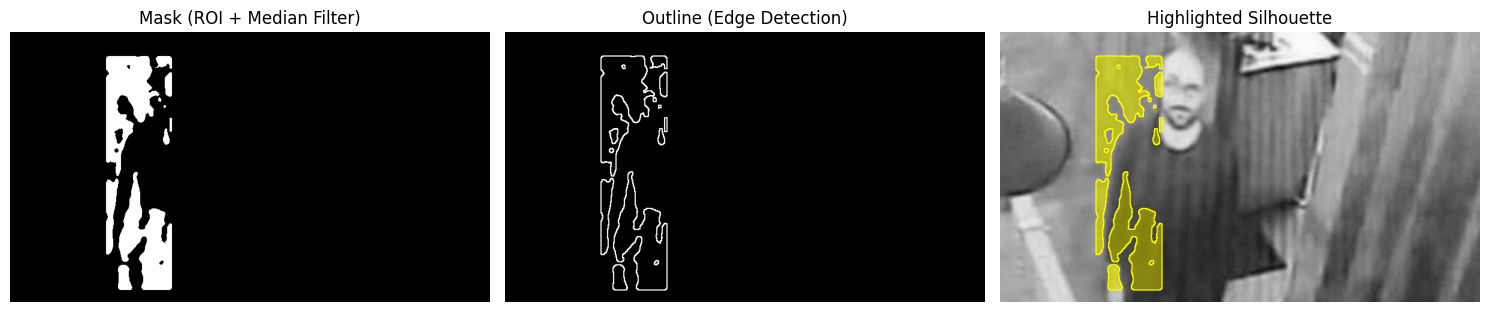

In [12]:
h, w = gambar1.shape

mask_roi = np.zeros((h, w), dtype=np.uint8)

batas_atas = 40
batas_bawah = 430
batas_kiri = 160
batas_kanan = 270

for i in range(batas_atas, batas_bawah):
    for j in range(batas_kiri, batas_kanan):
        if gambar1[i, j] < 65 or gambar1[i, j] > 140:
            mask_roi[i, j] = 255

mask_solid = filter_citra(mask_roi, 7, 'median')

outline_kasar = edge_detection(mask_solid, sobelx, sobely)
outline_final = np.zeros((h, w), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        if outline_kasar[i, j] > 20:
            outline_final[i, j] = 255

highlight = np.zeros((h, w, 3), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        v = gambar1[i, j]
        highlight[i, j] = [v, v, v]
        
        if mask_solid[i, j] == 255:
            highlight[i, j, 0] = int(0.6 * v + 0.4 * 255) 
            highlight[i, j, 1] = int(0.6 * v + 0.4 * 255) 
            highlight[i, j, 2] = int(0.3 * v)             
            
        if outline_final[i, j] == 255:
            highlight[i, j] = [255, 255, 0]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask_solid, cmap='gray')
plt.title('Mask (ROI + Median Filter)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(outline_final, cmap='gray')
plt.title('Outline (Edge Detection)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(highlight)
plt.title('Highlighted Silhouette')
plt.axis('off')

plt.tight_layout()
plt.show()

Proses ini membangun masker siluet secara manual melalui penentuan koordinat geometri untuk bagian kepala, leher, dan tubuh yang kemudian diperhalus menggunakan filter median untuk menghilangkan gangguan. Dari masker padat tersebut, garis tepi (outline) diekstraksi menggunakan operator Sobel agar diperoleh batas siluet yang tegas dan biner melalui tahap thresholding. Hasil akhirnya adalah citra highlight di mana area tubuh subjek diberi efek transparan kuning melalui manipulasi kanal BGR dan garis tepinya ditimpa dengan warna kuning solid, sehingga subjek manusia terisolasi dan tertonjolkan secara jelas pada citra asli.

**Cara Manual/ coba-coba agar hasil serupa dengan hasil di soal jurnal**

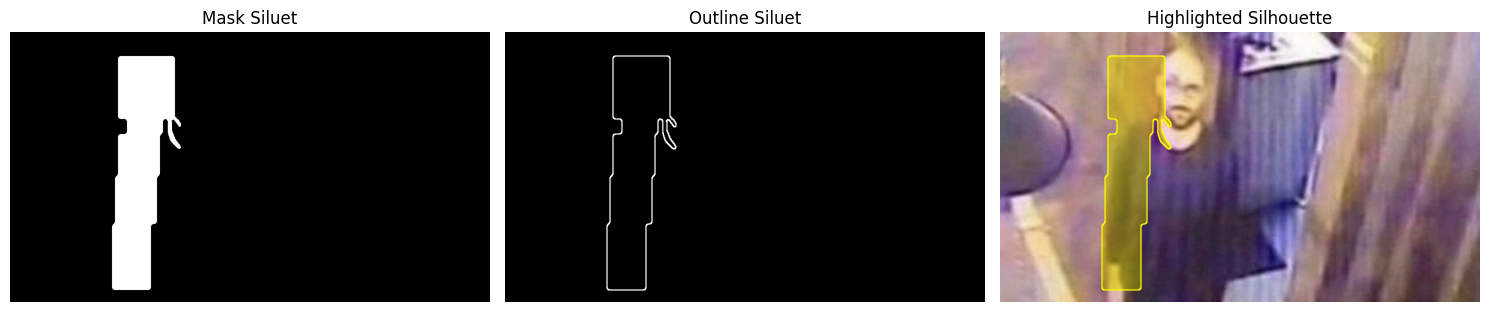

In [13]:
backup = cv2.imread('backup.jpg') 

mask = duaPuluh.copy()
height, width = mask.shape


mask_siluet = np.zeros_like(mask, dtype=np.uint8)

# Kepala (kotak)
for i in range(40, min(145, height)):
    for j in range(180, min(275, width)):
        mask_siluet[i, j] = 255

# Leher
for i in range(145, min(170, height)):
    for j in range(195, min(255, width)):
        mask_siluet[i, j] = 255

# Tubuh (trapesium)
for i in range(170, min(430, height)):
    # sisi kiri tubuh sedikit melengkung
    if i < 240:
        left = 180
    elif i < 320:
        left = 175
    else:
        left = 170

    # sisi kanan tubuh
    if i < 240:
        right = 250
    elif i < 320:
        right = 245
    else:
        right = 235

    for j in range(left, min(right, width)):
        mask_siluet[i, j] = 255

for i in range(60, min(220, height)):
    for j in range(220, min(320, width)):
        if mask[i, j] == 255:
            mask_siluet[i, j] = 255

for i in range(height):
    for j in range(285, width):
        mask_siluet[i, j] = 0


mask_siluet = cv2.medianBlur(mask_siluet, 7)
mask_siluet = thresholding(mask_siluet, 128)

outline = edge_detection(mask_siluet, sobelx, sobely)
outline = thresholding(outline, 20)


highlight = backup.copy()

for i in range(height):
    for j in range(width):
        if mask_siluet[i, j] == 255:
            # kuning transparan
            highlight[i, j, 0] = int(0.4 * highlight[i, j, 0])             # B
            highlight[i, j, 1] = int(0.7 * highlight[i, j, 1] + 0.3 * 255) # G
            highlight[i, j, 2] = int(0.7 * highlight[i, j, 2] + 0.3 * 255) # R

# garis outline kuning terang
for i in range(height):
    for j in range(width):
        if outline[i, j] == 255:
            highlight[i, j] = [0, 255, 255]   # BGR = kuning

highlight_rgb = cv2.cvtColor(highlight, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask_siluet, cmap='gray', vmin=0, vmax=255)
plt.title('Mask Siluet')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(outline, cmap='gray', vmin=0, vmax=255)
plt.title('Outline Siluet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(highlight_rgb)
plt.title('Highlighted Silhouette')
plt.axis('off')

plt.tight_layout()
plt.show()

# Deteksi Tepi dan Background Removal

Tahapan ini melakukan penghapusan latar belakang (background removal) dengan menggabungkan deteksi tepi dan logika warna chromakey. Masker biner dibuat secara manual dengan membandingkan intensitas kanal warna RGB untuk mengisolasi subjek dari latar belakangnya, yang kemudian diperhalus menggunakan filter median untuk membuang bintik-bintik noise. Hasil akhirnya adalah citra subjek utama yang dipertahankan warna aslinya dengan latar belakang yang telah diubah menjadi warna putih solid secara bersih dan kontras.

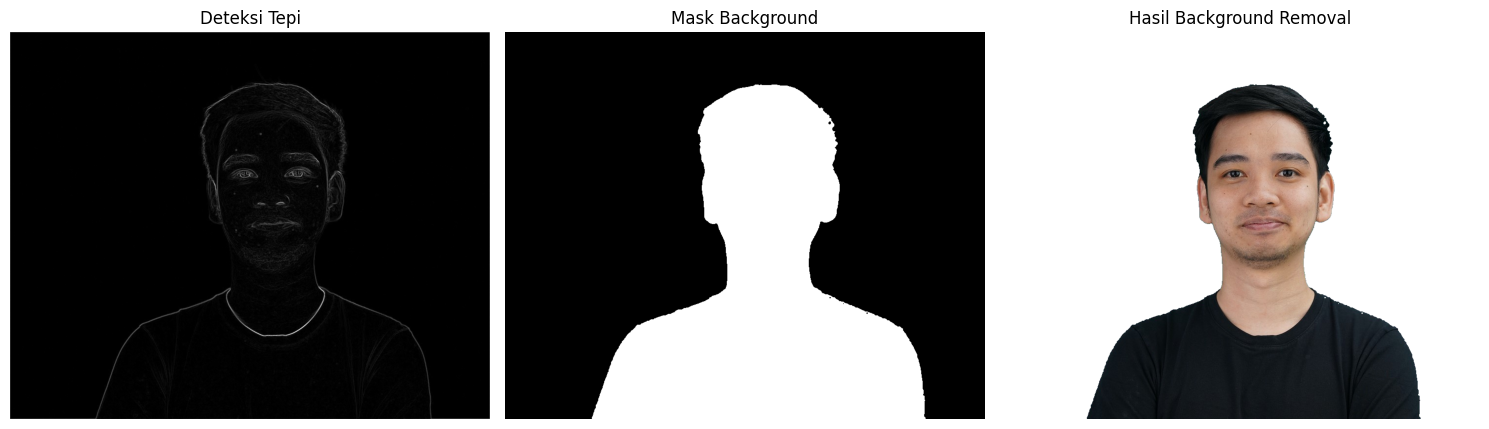

In [14]:
img_bgr = cv2.imread('david.jpg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) 

h, w, c = img_bgr.shape
img_rgb = np.zeros((h, w, 3), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        img_rgb[i, j, 0] = img_bgr[i, j, 2] 
        img_rgb[i, j, 1] = img_bgr[i, j, 1] 
        img_rgb[i, j, 2] = img_bgr[i, j, 0] 

tepi_david = edge_detection(img_gray, sobelx, sobely)

mask_kasar = np.zeros((h, w), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        r = int(img_rgb[i, j, 0])
        g = int(img_rgb[i, j, 1])
        b = int(img_rgb[i, j, 2])
        
        if g > (r + 20) and b > (r + 20):
            mask_kasar[i, j] = 0   
        else:
            mask_kasar[i, j] = 255  


mask_bersih = filter_citra(mask_kasar, 3, 'median')

david_final = np.zeros((h, w, 3), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        if mask_bersih[i, j] == 0:
            david_final[i, j, 0] = 255
            david_final[i, j, 1] = 255
            david_final[i, j, 2] = 255
        else:
            david_final[i, j, 0] = img_rgb[i, j, 0]
            david_final[i, j, 1] = img_rgb[i, j, 1]
            david_final[i, j, 2] = img_rgb[i, j, 2]


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(tepi_david, cmap='gray')
plt.title('Deteksi Tepi')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_bersih, cmap='gray')
plt.title('Mask Background')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(david_final)
plt.title('Hasil Background Removal')
plt.axis('off')

plt.tight_layout()
plt.show()

Visualisasi diatas melakukan segmentasi objek melalui kombinasi deteksi tepi Sobel dan logika thresholding warna RGB secara manual. Masker biner dibuat dengan mengevaluasi perbandingan intensitas kanal warna guna memisahkan subjek dari latar belakangnya, yang kemudian diperhalus menggunakan filter median 3×3 untuk membuang bintik noise di sekitar tepian. Hasil akhirnya menunjukkan keberhasilan isolasi subjek utama, di mana area latar belakang yang teridentifikasi oleh masker diubah menjadi warna putih solid secara kontras tanpa menghilangkan detail warna asli pada subjek.

# Kesimpulan

Perbaikan kualitas citra melalui teknik Smoothing dan Sharpening merupakan tahapan prapemrosesan krusial untuk menyeimbangkan antara reduksi noise dan penajaman detail fitur. Dalam praktikum ini, terbukti bahwa smoothing efektif meminimalisir gangguan bintik pada latar belakang, sementara sharpening mempertegas batas intensitas yang sempat kabur. Sinergi kedua metode ini menghasilkan citra yang lebih optimal sebagai input bagi algoritma Deteksi Tepi (Prewitt, Sobel, dan Roberts), karena kualitas tepi yang dihasilkan sangat bergantung pada kebersihan dan kontras citra asalnya.

Penggunaan berbagai operator gradien memberikan pemahaman bahwa setiap kernel memiliki karakteristik unik; operator Sobel dan Prewitt unggul dalam menghasilkan garis tepi yang kontinu dan stabil, sedangkan Roberts sangat sensitif terhadap detail diagonal yang tajam. Proses Normalisasi manual menjadi kunci teknis yang sangat penting untuk memetakan kembali akumulasi nilai piksel ke rentang 0–255, sehingga mencegah terjadinya overflow atau saturasi saat beberapa hasil deteksi tepi dijumlahkan. Hal ini kemudian disempurnakan dengan teknik Thresholding biner, di mana pemilihan nilai ambang yang tepat menentukan keberhasilan dalam memisahkan siluet subjek dari gangguan latar belakang secara bersih.

Secara keseluruhan, materi pada Modul 3 ini telah memenuhi ketercapaian CPMK (Capaian Pembelajaran Mata Kuliah), khususnya dalam kemampuan mengimplementasikan algoritma pengolahan citra pada domain spasial secara mandiri melalui pemrograman Python. Mahasiswa tidak hanya mampu menerapkan teori konvolusi dan filter statistik, tetapi juga mampu melakukan analisis mendalam terhadap manipulasi Region of Interest (ROI) dan logika color blending untuk aplikasi nyata seperti highlighting siluet pada citra CCTV serta background removal. Kemampuan untuk membangun fungsi pengolahan citra secara manual (tanpa hanya bergantung pada pustaka instan) menunjukkan penguasaan kompetensi dasar yang kuat dalam memecahkan persoalan komputasi citra digital secara sistematis.